# Deep Convolutional Generative Adversarial Network (DCGAN)


In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import numpy as np

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")


## Data Loading and Visualization

In [11]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

emnist = datasets.EMNIST(root='./data', split='letters', train=True, download=True, transform=transform)
dataloader = DataLoader(emnist, batch_size=64, shuffle=True)


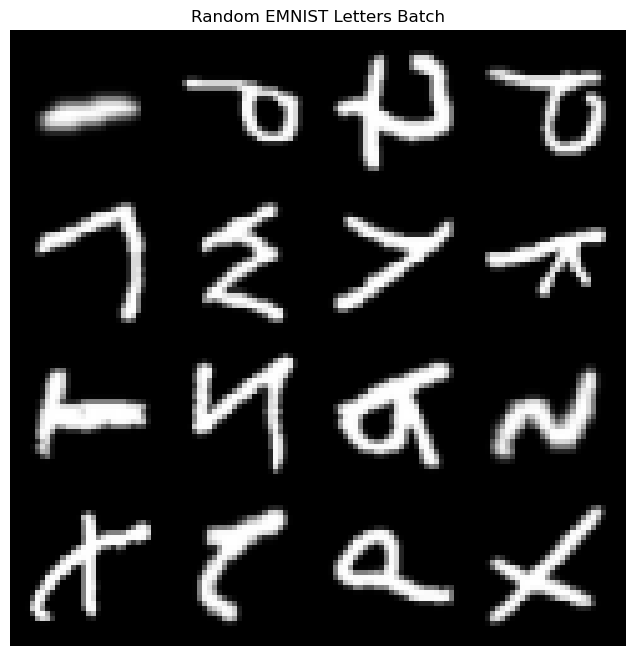

Labels: ['i', 'b', 'j', 'b', 'l', 'm', 'y', 'k', 't', 'z', 'r', 's', 'f', 'r', 'g', 'x']


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision

dataiter = iter(dataloader)
images, labels = next(dataiter)

num_images = 16
images = images[:num_images]
labels = labels[:num_images]

images = images / 2 + 0.5

img_grid = torchvision.utils.make_grid(images, nrow=4)

np_img = img_grid.numpy()
np_img = np.transpose(np_img, (1, 2, 0))

plt.figure(figsize=(8, 8))
plt.imshow(np_img)
plt.axis('off')
plt.title("Random EMNIST Letters Batch")
plt.show()

print("Labels:", [chr(l.item() + 96) for l in labels])

## Model Definition

### Generator Definition

In [13]:
# This model takes a batch of compressed noisy vectors and uses them to generate
# new realistic samples
class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # Input shape: (batch_size, 100, 1, 1)
        self.main = nn.Sequential(
            # Transposed convolution (100, 128, 7, 1, 0)
            nn.ConvTranspose2d(100, 128, kernel_size=7, stride=1, padding=0),
            # -> Batch Normalization layer
            nn.BatchNorm2d(128),
            # -> relu
            nn.ReLU(),

            # This block takes the 100-channel input vector of spatial size 1x1
            # and expands the spatial size to a 7x7 feature map while simultaneously
            # expanding the depth to 128 channels

            # Transposed convolution (128, 64, 4, 2, 1)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            # -> Batch Normalization layer
            nn.BatchNorm2d(64),
            # -> relu
            nn.ReLU(),

            # This block doubles the spatial dimensions while narrowing the channel depth.
            # A stride of 2 combined with a kernel size of 4 and padding of 1 acts as a clean
            # 2x upsampler

            # Transposed convolution (64, 1, 4, 2, 1)
            nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1),
            # -> tanh
            nn.Tanh()

            # This final upsampling stage performs another 2x scale-up, bringing the spatial
            # dimensions from 14x14 up to 28x28. It also condenses the 64 feature channels down
            # to 1 single channel (perfect for grayscale EMNIST letters)

            # Note: tanh function clamps the output pixel values strictly between [-1, 1]
        )

    def forward(self, x):
        return self.main(x)
    
generator = Generator().to(device)
print(generator)

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 128, kernel_size=(7, 7), stride=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)


### Discrimator Definiton

In [14]:
# This model tells whether input images are real (1) or fake (0)
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.main = nn.Sequential(
            # Conv layer (1, 64, 4, 2, 1)
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            # -> Leaky ReLU (0.2)
            nn.LeakyReLU(0.2),

            # This block takes the 1-channel image and passes 64 conv filters over it.
            # Since stride is 2, the spatial dimensions is cut in half (28x28 -> 14x14)

            # Conv layer (64, 128, 4, 2, 1)
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            # -> Batch Normalization
            nn.BatchNorm2d(128),
            # -> Leaky ReLU (0.2)
            nn.LeakyReLU(0.2),

            # This block extracts deeper features

            # Flattening
            nn.Flatten(),
            # -> Linear
            nn.Linear(128 * 7 * 7, 1),
            # -> Sigmoid
            nn.Sigmoid()

            # This block outputs the final probability between 0 and 1
            # 0 means completely fake, 1 means completely real
        )

    def forward(self, x):
        return self.main(x)

discriminator = Discriminator().to(device)
print(discriminator)

Discriminator(
  (main): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Flatten(start_dim=1, end_dim=-1)
    (6): Linear(in_features=6272, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


## Training Loop

In [15]:
criterion = nn.BCELoss()
optimizerD = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerG = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [16]:
num_epochs = 25
fixed_noise = torch.randn(64, 100, 1, 1, device=device)

for epoch in range(num_epochs):
    for i, (real_imgs, _) in enumerate(dataloader):

        # Real images from dataset
        real_imgs = real_imgs.to(device)
        b_size = real_imgs.size(0)

        # Batch of noisy vectors the generator will reshape into realistic samples
        noise = torch.randn(b_size, 100, 1, 1, device=device)

        # Vector of ones representing real images
        real_label = torch.ones(b_size, 1, device=device)

        # Vector of zeros representing fake images
        fake_label = torch.zeros(b_size, 1, device=device)

        # TRAIN DISCRIMINATOR

        optimizerD.zero_grad()

        # Real samples
        output_real = discriminator(real_imgs)
        loss_real = criterion(output_real, real_label)

        # Fake samples are detached so D does not backprop into G here
        fake_imgs = generator(noise).detach()
        output_fake = discriminator(fake_imgs)
        loss_fake = criterion(output_fake, fake_label)

        lossD = loss_real + loss_fake
        lossD.backward()
        optimizerD.step()

        # TRAIN GENERATOR

        optimizerG.zero_grad()

        # Recompute fake images without detach so G gets gradients
        fake_imgs = generator(noise)
        output = discriminator(fake_imgs)
        lossG = criterion(output, real_label)

        lossG.backward()
        optimizerG.step()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss D: {lossD.item():.4f}, Loss G: {lossG.item():.4f}")


Epoch [1/25], Loss D: 0.2937, Loss G: 2.6347
Epoch [2/25], Loss D: 0.2226, Loss G: 3.4533
Epoch [3/25], Loss D: 0.2237, Loss G: 3.7612
Epoch [4/25], Loss D: 0.2779, Loss G: 3.7768
Epoch [5/25], Loss D: 0.2947, Loss G: 1.7213
Epoch [6/25], Loss D: 0.1686, Loss G: 3.8972
Epoch [7/25], Loss D: 0.0770, Loss G: 5.0174
Epoch [8/25], Loss D: 0.1303, Loss G: 4.6064
Epoch [9/25], Loss D: 0.3529, Loss G: 2.9753
Epoch [10/25], Loss D: 0.1819, Loss G: 3.1954
Epoch [11/25], Loss D: 0.1617, Loss G: 3.7160
Epoch [12/25], Loss D: 0.1258, Loss G: 3.8950
Epoch [13/25], Loss D: 0.2240, Loss G: 4.6270
Epoch [14/25], Loss D: 0.2283, Loss G: 4.4643
Epoch [15/25], Loss D: 0.1336, Loss G: 4.3346
Epoch [16/25], Loss D: 0.1583, Loss G: 4.3519
Epoch [17/25], Loss D: 0.1349, Loss G: 4.2037
Epoch [18/25], Loss D: 0.3235, Loss G: 3.5495
Epoch [19/25], Loss D: 0.1240, Loss G: 5.0686
Epoch [20/25], Loss D: 0.1408, Loss G: 4.4936
Epoch [21/25], Loss D: 0.1910, Loss G: 4.6114
Epoch [22/25], Loss D: 0.8974, Loss G: 0.90

## Validation (New Samples Generation)

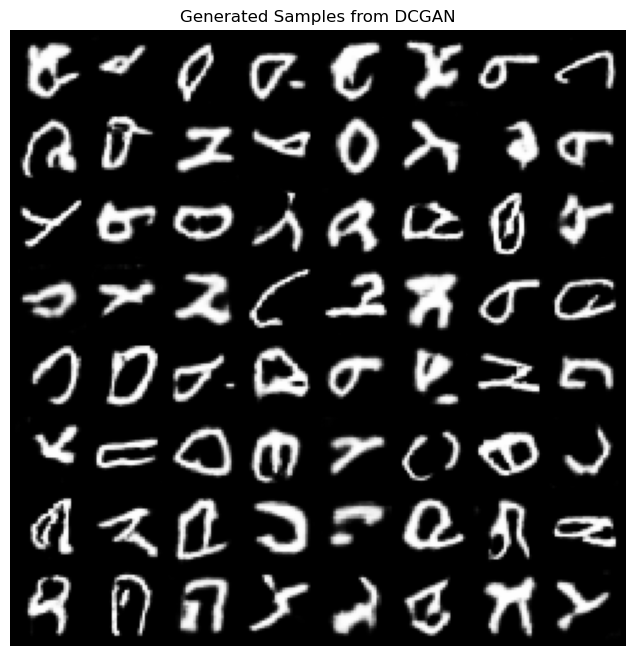

In [17]:
generator.eval()
with torch.no_grad():
    fake_samples = generator(fixed_noise).cpu()
grid = make_grid(fake_samples, nrow=8, normalize=True)
plt.figure(figsize=(8,8))
plt.axis("off")
plt.title("Generated Samples from DCGAN")
plt.imshow(np.transpose(grid, (1,2,0)))
plt.show()
